<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/semana4/ensamblados_bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de ensamblado con datos reales: Bank Marketing (UCI)

Comparación entre **Árbol de Decisión, Bagging, Random Forest, Gradient Boosting y XGBoost**.

El cuaderno descarga datos reales del problema **Bank Marketing** del UCI Machine Learning Repository (versión `bank-additional-full`, 41.188 registros), realiza el preprocesamiento y compara los modelos mediante Accuracy, Precision, Recall, F1 y ROC-AUC.

También muestra explícitamente cómo **Bagging combina las predicciones de muchos árboles**, que es la parte central para visualizar la noción de ensamblado.

In [2]:
# Si estás en Google Colab y XGBoost no estuviera instalado, ejecuta:
%pip install -q xgboost

In [3]:
from pathlib import Path
from urllib.request import urlretrieve
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from xgboost import XGBClassifier


In [4]:
# =============================================================================
# 0. CONFIGURACIÓN
# =============================================================================

RANDOM_STATE = 42
TEST_SIZE = 0.25
N_ESTIMATORS = 100

# Si se pone True, se elimina "duration".
# Esto es apropiado si el objetivo de negocio es decidir A QUIÉN LLAMAR antes
# de que ocurra la llamada, porque la duración solo se conoce después.
ELIMINAR_DURATION = False

# Mostrar las figuras además de guardarlas.
MOSTRAR_GRAFICAS = True

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_FILE = BASE_DIR / "bank-additional-full.csv"
OUTPUT_DIR = BASE_DIR / "salidas_ensamblados"
OUTPUT_DIR.mkdir(exist_ok=True)

# Espejo público del archivo bank-additional-full.csv del dataset UCI.
# Se usa un archivo raw para que pandas pueda leerlo directamente.
DATA_URL = (
    "https://raw.githubusercontent.com/selva86/datasets/"
    "master/bank-full.csv"
)


In [5]:
# =============================================================================
# 1. CARGA DE DATOS
# =============================================================================

def cargar_datos() -> pd.DataFrame:
    """Carga el dataset localmente; si no existe, lo descarga de Internet."""

    if not DATA_FILE.exists():
        print("\nDescargando Bank Marketing...")
        try:
            urlretrieve(DATA_URL, DATA_FILE)
        except Exception as exc:
            raise RuntimeError(
                "No fue posible descargar el dataset. Verifica tu conexión a "
                "Internet o coloca 'bank-additional-full.csv' en la misma "
                "carpeta del programa."
            ) from exc
        print(f"Dataset guardado en: {DATA_FILE}")
    else:
        print(f"\nUsando dataset local: {DATA_FILE}")

    # El archivo UCI utiliza punto y coma como separador.
    df = pd.read_csv(DATA_FILE, sep=";")

    # Verificación mínima para evitar trabajar accidentalmente con otro CSV.
    columnas_necesarias = {"age", "job", "duration", "campaign", "y"}
    faltantes = columnas_necesarias.difference(df.columns)
    if faltantes:
        raise ValueError(
            "El archivo encontrado no parece ser el Bank Marketing esperado. "
            f"Faltan columnas: {sorted(faltantes)}"
        )

    return df


df = cargar_datos()

print("\n" + "=" * 72)
print("DATASET")
print("=" * 72)
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("\nPrimeras 5 observaciones:")
print(df.head())

print("\nDistribución de la variable objetivo:")
print(df["y"].value_counts())
print("\nProporciones:")
print(df["y"].value_counts(normalize=True).round(4))



Descargando Bank Marketing...
Dataset guardado en: /content/bank-additional-full.csv

DATASET
Filas:    41,188
Columnas: 21

Primeras 5 observaciones:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent   

In [6]:
# =============================================================================
# 2. VARIABLES X E y
# =============================================================================

X = df.drop(columns="y").copy()
y = df["y"].map({"no": 0, "yes": 1})

if y.isna().any():
    raise ValueError("La variable objetivo contiene valores distintos de yes/no.")

y = y.astype(int)

if ELIMINAR_DURATION and "duration" in X.columns:
    X = X.drop(columns="duration")
    print("\nSe eliminó 'duration' para simular una predicción previa a la llamada.")

columnas_numericas = X.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nVariables numéricas:")
print(columnas_numericas)
print("\nVariables categóricas:")
print(columnas_categoricas)



Variables numéricas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [7]:
# =============================================================================
# 3. DIVISIÓN TRAIN / TEST
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\n" + "=" * 72)
print("DIVISIÓN DE DATOS")
print("=" * 72)
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")



DIVISIÓN DE DATOS
Entrenamiento: (30891, 20)
Prueba:        (10297, 20)


In [8]:
# =============================================================================
# 4. PREPROCESAMIENTO
# =============================================================================

pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, columnas_numericas),
        ("categoricas", pipeline_categorico, columnas_categoricas),
    ]
)

# IMPORTANTE: fit_transform SOLO sobre entrenamiento.
X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc = preprocesador.transform(X_test)

print("\nDespués del One-Hot Encoding:")
print(f"X_train: {X_train.shape} -> {X_train_proc.shape}")
print(f"X_test:  {X_test.shape} -> {X_test_proc.shape}")



Después del One-Hot Encoding:
X_train: (30891, 20) -> (30891, 63)
X_test:  (10297, 20) -> (10297, 63)


In [9]:
# =============================================================================
# 5. DEFINICIÓN DE LOS MODELOS
# =============================================================================

modelos = {
    "Árbol individual": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    ),

    # BAGGING:
    # Muchos árboles entrenados con muestras bootstrap diferentes.
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=N_ESTIMATORS,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    # RANDOM FOREST:
    # Bagging + selección aleatoria de variables en cada división.
    "Random Forest": RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    # GRADIENT BOOSTING:
    # Los árboles se agregan secuencialmente para corregir el modelo previo.
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),

    # XGBOOST:
    # Boosting optimizado con regularización y muestreo de filas/columnas.
    "XGBoost": XGBClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}


In [10]:
# =============================================================================
# 6. FUNCIÓN DE EVALUACIÓN
# =============================================================================

def evaluar_modelo(nombre, modelo):
    """Entrena un modelo y devuelve métricas, clases y probabilidades."""

    inicio = time.perf_counter()
    modelo.fit(X_train_proc, y_train)
    tiempo = time.perf_counter() - inicio

    y_pred = modelo.predict(X_test_proc)
    y_prob = modelo.predict_proba(X_test_proc)[:, 1]

    resultado = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Tiempo_s": tiempo,
    }

    return resultado, y_pred, y_prob


In [11]:
# =============================================================================
# 7. ENTRENAMIENTO DE TODOS LOS MODELOS
# =============================================================================

resultados = []
modelos_entrenados = {}
predicciones = {}
probabilidades = {}

print("\n" + "=" * 72)
print("ENTRENAMIENTO")
print("=" * 72)

for nombre, modelo in modelos.items():
    print(f"\nEntrenando: {nombre}")

    resultado, y_pred, y_prob = evaluar_modelo(nombre, modelo)

    resultados.append(resultado)
    modelos_entrenados[nombre] = modelo
    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_prob

    print(f"  Accuracy : {resultado['Accuracy']:.4f}")
    print(f"  Precision: {resultado['Precision']:.4f}")
    print(f"  Recall   : {resultado['Recall']:.4f}")
    print(f"  F1       : {resultado['F1']:.4f}")
    print(f"  ROC-AUC  : {resultado['ROC_AUC']:.4f}")
    print(f"  Tiempo   : {resultado['Tiempo_s']:.2f} s")



ENTRENAMIENTO

Entrenando: Árbol individual
  Accuracy : 0.8855
  Precision: 0.4921
  Recall   : 0.5103
  F1       : 0.5011
  ROC-AUC  : 0.7217
  Tiempo   : 0.32 s

Entrenando: Bagging
  Accuracy : 0.9172
  Precision: 0.6607
  Recall   : 0.5440
  F1       : 0.5967
  ROC-AUC  : 0.9441
  Tiempo   : 20.92 s

Entrenando: Random Forest
  Accuracy : 0.9161
  Precision: 0.6942
  Recall   : 0.4560
  F1       : 0.5505
  ROC-AUC  : 0.9436
  Tiempo   : 3.03 s

Entrenando: Gradient Boosting
  Accuracy : 0.9186
  Precision: 0.6949
  Recall   : 0.4948
  F1       : 0.5780
  ROC-AUC  : 0.9503
  Tiempo   : 8.71 s

Entrenando: XGBoost
  Accuracy : 0.9174
  Precision: 0.7074
  Recall   : 0.4543
  F1       : 0.5533
  ROC-AUC  : 0.9502
  Tiempo   : 0.57 s


In [12]:
# =============================================================================
# 8. TABLA FINAL DE COMPARACIÓN
# =============================================================================

df_resultados = (
    pd.DataFrame(resultados)
    .sort_values(by="ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 72)
print("RESULTADOS FINALES — ORDENADOS POR ROC-AUC")
print("=" * 72)
print(df_resultados.round(4).to_string(index=False))

ruta_resultados = OUTPUT_DIR / "comparacion_modelos.csv"
df_resultados.to_csv(ruta_resultados, index=False)
print(f"\nTabla guardada en: {ruta_resultados}")



RESULTADOS FINALES — ORDENADOS POR ROC-AUC
           Modelo  Accuracy  Precision  Recall     F1  ROC_AUC  Tiempo_s
Gradient Boosting    0.9186     0.6949  0.4948 0.5780   0.9503    8.7067
          XGBoost    0.9174     0.7074  0.4543 0.5533   0.9502    0.5682
          Bagging    0.9172     0.6607  0.5440 0.5967   0.9441   20.9155
    Random Forest    0.9161     0.6942  0.4560 0.5505   0.9436    3.0295
 Árbol individual    0.8855     0.4921  0.5103 0.5011   0.7217    0.3219

Tabla guardada en: /content/salidas_ensamblados/comparacion_modelos.csv


In [13]:
# =============================================================================
# 9. DEMOSTRACIÓN EXPLÍCITA DEL BAGGING
# =============================================================================

bag = modelos_entrenados["Bagging"]

# Tomamos el primer cliente del conjunto de prueba.
cliente = X_test_proc[0:1]
valor_real = int(y_test.iloc[0])

print("\n" + "=" * 72)
print("CÓMO FUNCIONA EL ENSAMBLADO EN BAGGING")
print("=" * 72)
print(f"Valor real del cliente: {valor_real}")
print("\nPredicciones de los primeros 15 árboles:")

votos = []
for i, estimador in enumerate(bag.estimators_[:15], start=1):
    voto = int(estimador.predict(cliente)[0])
    votos.append(voto)
    print(f"  Árbol {i:02d}: {voto}")

probas_cliente = np.array(
    [estimador.predict_proba(cliente)[0, 1] for estimador in bag.estimators_]
)

promedio_manual = probas_cliente.mean()
promedio_bagging = bag.predict_proba(cliente)[0, 1]
prediccion_final = int(bag.predict(cliente)[0])

print("\nPromedio manual de probabilidades de todos los árboles:")
print(f"  {promedio_manual:.6f}")
print("Probabilidad producida por Bagging:")
print(f"  {promedio_bagging:.6f}")
print("Predicción final de Bagging:")
print(f"  {prediccion_final}")

# Verificamos numéricamente que el promedio manual coincide con Bagging.
assert np.isclose(promedio_manual, promedio_bagging), (
    "El promedio manual de probabilidades no coincide con predict_proba de Bagging."
)



CÓMO FUNCIONA EL ENSAMBLADO EN BAGGING
Valor real del cliente: 1

Predicciones de los primeros 15 árboles:
  Árbol 01: 0
  Árbol 02: 0
  Árbol 03: 0
  Árbol 04: 0
  Árbol 05: 0
  Árbol 06: 0
  Árbol 07: 0
  Árbol 08: 1
  Árbol 09: 1
  Árbol 10: 0
  Árbol 11: 0
  Árbol 12: 0
  Árbol 13: 1
  Árbol 14: 0
  Árbol 15: 0

Promedio manual de probabilidades de todos los árboles:
  0.410000
Probabilidad producida por Bagging:
  0.410000
Predicción final de Bagging:
  0


In [14]:
# =============================================================================
# 10. TABLA DE ENSAMBLADO PARA 10 CLIENTES
# =============================================================================

N_DEMO = 10
X_demo = X_test_proc[:N_DEMO]
y_demo = y_test.iloc[:N_DEMO].to_numpy()

probas_arboles = np.column_stack(
    [estimador.predict_proba(X_demo)[:, 1] for estimador in bag.estimators_]
)

tabla_ensamblado = pd.DataFrame({"Real": y_demo})

# Mostramos 8 árboles individuales para que la tabla sea legible.
for i in range(8):
    tabla_ensamblado[f"Árbol_{i+1}"] = probas_arboles[:, i]

tabla_ensamblado["Promedio_todos_los_arboles"] = probas_arboles.mean(axis=1)
tabla_ensamblado["Prediccion_Bagging"] = (
    tabla_ensamblado["Promedio_todos_los_arboles"] >= 0.5
).astype(int)

print("\nEjemplo de combinación de probabilidades para 10 clientes:")
print(tabla_ensamblado.round(3).to_string(index=False))

ruta_ensamblado = OUTPUT_DIR / "demostracion_bagging.csv"
tabla_ensamblado.to_csv(ruta_ensamblado, index=False)



Ejemplo de combinación de probabilidades para 10 clientes:
 Real  Árbol_1  Árbol_2  Árbol_3  Árbol_4  Árbol_5  Árbol_6  Árbol_7  Árbol_8  Promedio_todos_los_arboles  Prediccion_Bagging
    1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      1.0                        0.41                   0
    0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0                        0.00                   0
    0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0                        0.16                   0
    0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0                        0.00                   0
    0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0                        0.00                   0
    0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0                        0.00                   0
    0      0.0      0.0      0.0      0.0      0.0      0.

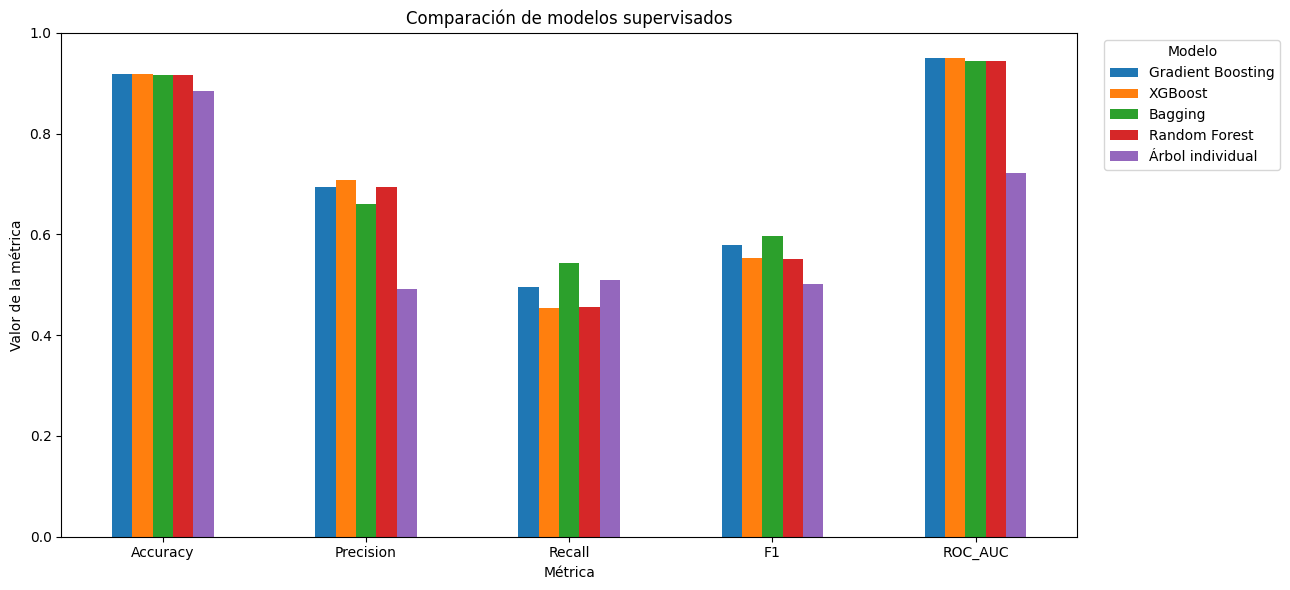

In [15]:
# =============================================================================
# 11. GRÁFICA COMPARATIVA DE MÉTRICAS
# =============================================================================

metricas = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
df_grafica = df_resultados.set_index("Modelo")[metricas].T

ax = df_grafica.plot(kind="bar", figsize=(13, 6))
ax.set_title("Comparación de modelos supervisados")
ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("Métrica")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

ruta_fig = OUTPUT_DIR / "comparacion_metricas.png"
plt.savefig(ruta_fig, dpi=160, bbox_inches="tight")
if MOSTRAR_GRAFICAS:
    plt.show()
else:
    plt.close()


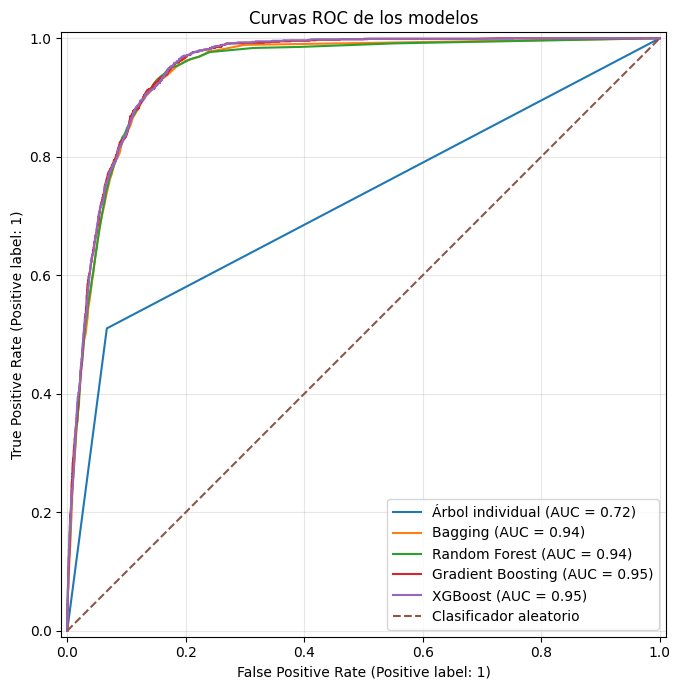

In [16]:
# =============================================================================
# 12. CURVAS ROC
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 7))

for nombre in modelos.keys():
    RocCurveDisplay.from_predictions(
        y_test,
        probabilidades[nombre],
        name=nombre,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], "--", label="Clasificador aleatorio")
ax.set_title("Curvas ROC de los modelos")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

ruta_roc = OUTPUT_DIR / "curvas_roc.png"
plt.savefig(ruta_roc, dpi=160, bbox_inches="tight")
if MOSTRAR_GRAFICAS:
    plt.show()
else:
    plt.close()


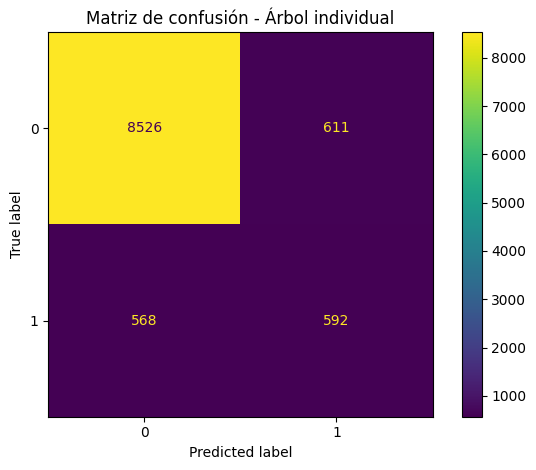

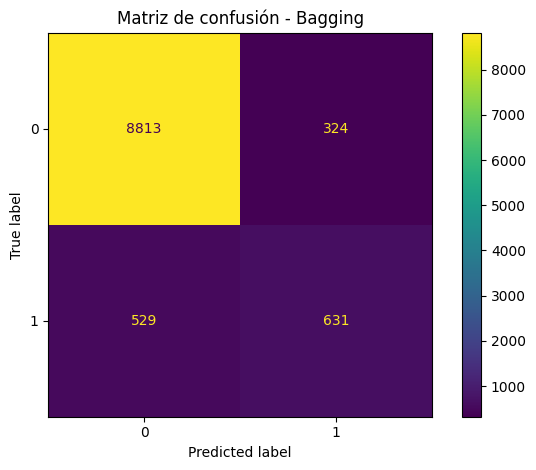

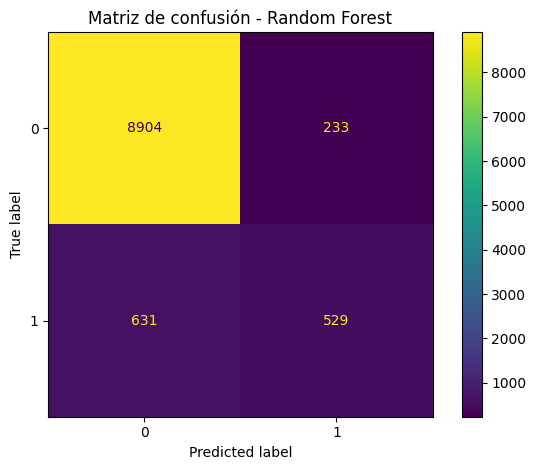

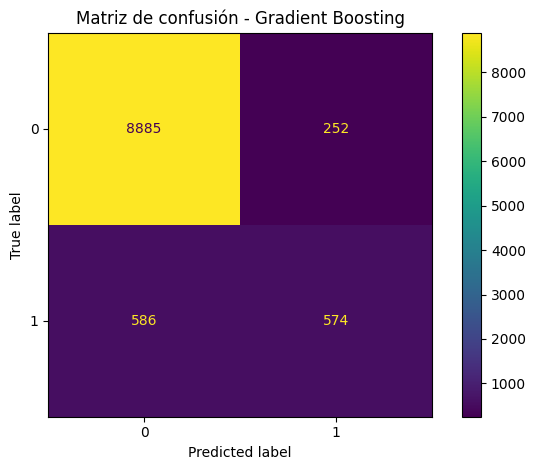

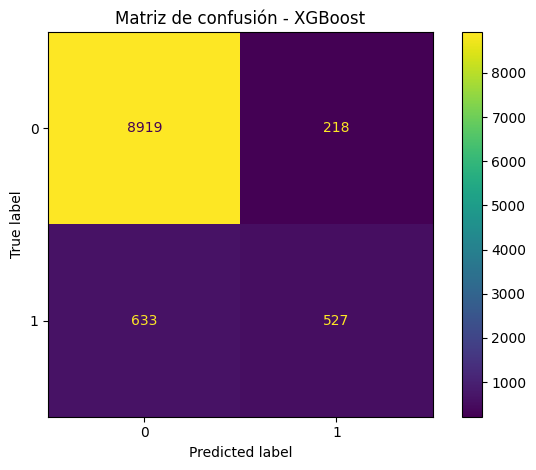

In [17]:
# =============================================================================
# 13. MATRICES DE CONFUSIÓN
# =============================================================================

for nombre in modelos.keys():
    cm = confusion_matrix(y_test, predicciones[nombre])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.tight_layout()

    nombre_archivo = (
        nombre.lower()
        .replace(" ", "_")
        .replace("á", "a")
        .replace("ó", "o")
    )
    plt.savefig(
        OUTPUT_DIR / f"matriz_confusion_{nombre_archivo}.png",
        dpi=160,
        bbox_inches="tight",
    )

    if MOSTRAR_GRAFICAS:
        plt.show()
    else:
        plt.close()



15 VARIABLES MÁS IMPORTANTES SEGÚN RANDOM FOREST
                                Variable  Importancia
                     numericas__duration     0.276698
                    numericas__euribor3m     0.094739
                          numericas__age     0.080921
                  numericas__nr.employed     0.048019
                     numericas__campaign     0.040069
                        numericas__pdays     0.029962
                numericas__cons.conf.idx     0.024094
                 numericas__emp.var.rate     0.023445
               numericas__cons.price.idx     0.022332
           categoricas__poutcome_success     0.018272
                 categoricas__housing_no     0.013271
                categoricas__housing_yes     0.012942
                 categoricas__job_admin.     0.012277
categoricas__education_university.degree     0.012106
            categoricas__marital_married     0.012023


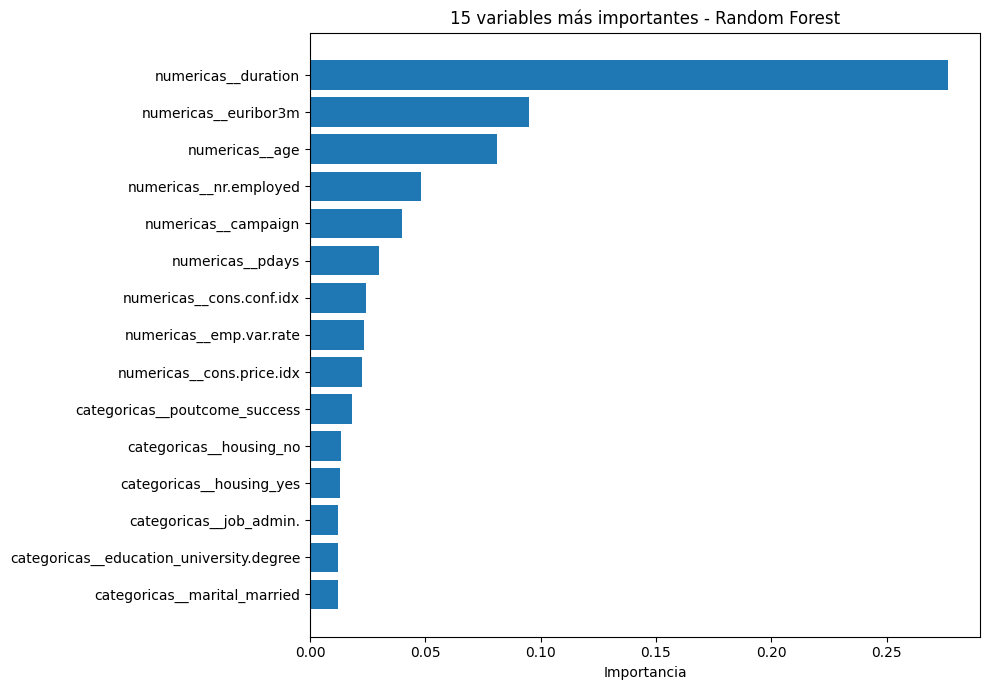

In [18]:
# =============================================================================
# 14. IMPORTANCIA DE VARIABLES EN RANDOM FOREST
# =============================================================================

nombres_variables = preprocesador.get_feature_names_out()
rf = modelos_entrenados["Random Forest"]

importancias = (
    pd.DataFrame(
        {
            "Variable": nombres_variables,
            "Importancia": rf.feature_importances_,
        }
    )
    .sort_values("Importancia", ascending=False)
    .head(15)
)

print("\n" + "=" * 72)
print("15 VARIABLES MÁS IMPORTANTES SEGÚN RANDOM FOREST")
print("=" * 72)
print(importancias.to_string(index=False))

ruta_importancias = OUTPUT_DIR / "importancias_random_forest.csv"
importancias.to_csv(ruta_importancias, index=False)

plt.figure(figsize=(10, 7))
plt.barh(
    importancias["Variable"][::-1],
    importancias["Importancia"][::-1],
)
plt.xlabel("Importancia")
plt.title("15 variables más importantes - Random Forest")
plt.tight_layout()

ruta_imp_fig = OUTPUT_DIR / "importancias_random_forest.png"
plt.savefig(ruta_imp_fig, dpi=160, bbox_inches="tight")
if MOSTRAR_GRAFICAS:
    plt.show()
else:
    plt.close()


In [19]:
# =============================================================================
# 15. RESUMEN CONCEPTUAL
# =============================================================================

print("\n" + "=" * 72)
print("RESUMEN CONCEPTUAL")
print("=" * 72)
print(
    """
Árbol individual:
    Un solo árbol. Es interpretable, pero puede tener alta varianza.

Bagging:
    Muchos árboles entrenados sobre muestras bootstrap diferentes.
    Sus predicciones se combinan por votación/promedio.
    Objetivo principal: reducir varianza.

Random Forest:
    Bagging + selección aleatoria de variables en cada división.
    Esto reduce la correlación entre los árboles.

Gradient Boosting:
    Árboles construidos secuencialmente.
    Cada nuevo árbol intenta mejorar el modelo acumulado.

XGBoost:
    Implementación optimizada de gradient boosting con regularización,
    muestreo de observaciones/variables y varias mejoras computacionales.
"""
)

print("Archivos producidos:")
for ruta in sorted(OUTPUT_DIR.iterdir()):
    print(f"  - {ruta.name}")

print("\nEjecución terminada correctamente.")



RESUMEN CONCEPTUAL

Árbol individual:
    Un solo árbol. Es interpretable, pero puede tener alta varianza.

Bagging:
    Muchos árboles entrenados sobre muestras bootstrap diferentes.
    Sus predicciones se combinan por votación/promedio.
    Objetivo principal: reducir varianza.

Random Forest:
    Bagging + selección aleatoria de variables en cada división.
    Esto reduce la correlación entre los árboles.

Gradient Boosting:
    Árboles construidos secuencialmente.
    Cada nuevo árbol intenta mejorar el modelo acumulado.

XGBoost:
    Implementación optimizada de gradient boosting con regularización,
    muestreo de observaciones/variables y varias mejoras computacionales.

Archivos producidos:
  - comparacion_metricas.png
  - comparacion_modelos.csv
  - curvas_roc.png
  - demostracion_bagging.csv
  - importancias_random_forest.csv
  - importancias_random_forest.png
  - matriz_confusion_arbol_individual.png
  - matriz_confusion_bagging.png
  - matriz_confusion_gradient_boosting.p